In [1]:
import random
from scipy.stats.mstats import gmean

In [2]:
import numpy as np
import pandas as pd
from pycaret.regression import get_config
from pycaret.regression import set_config
from pycaret.regression import (
    setup,
    compare_models,
    create_model,
    tune_model,
    ensemble_model,
    models,
    blend_models,
    stack_models,
    plot_model,
    evaluate_model,
    interpret_model,
    automl,
    predict_model,
    save_model,
    load_model,
    convert_model,
    create_api,
    create_docker,
    predict_model
)
from pycaret.utils import version
from yellowbrick.regressor import CooksDistance

In [3]:
id_cols = ['productID',"name","pProductID", "wine_url","pageName","uploadDate"]
target_cols = ['WS']
categorical_cols=[
    "description", "productPrice", "productCompetitiveIntensity", "ProductAvailability", "priceCurrency", 	"additionalType" ,"productOrigin", "productVarietal", "productRegion"
]
extra_cols=["shippingRegion", "shipToState"]
other_ratings = [ 'JS', 'WW', 'D', 'BH', 'W&S', 'WE', 'RP', 'JD', 'SJ', 'V', 'CG', 'TP' ]
predictors = [
    'productStock',
    'price',
    'prodAlcoholPercent_percent'
    #'averageRating_bestRating',
    #'averageRating_worstRating',
    #'bestRating',
    #'worstRating',
    #'prodAlcoholVolume_text',
]
model_columns = ['ws_pred_meta','ws_pred_other']

In [5]:
print(f"pycaret version = {version()}")
print("1. Loading Dataset")
df = pd.read_csv("../wines_ship_to_pa.csv")
df = df.drop_duplicates('wine_url') 

pycaret version = 3.0.3
1. Loading Dataset


In [6]:
df['prodAlcoholVolume_text'].unique()
[750., 0., 1500., 375., 187., 1000.,  500., 3000.,700., 6000.]

[750.0, 0.0, 1500.0, 375.0, 187.0, 1000.0, 500.0, 3000.0, 700.0, 6000.0]

In [7]:
df = df[df['prodAlcoholVolume_text']==750]

In [10]:
virtual_ws_meta = load_model("tml_wine_infer/models/predict_ws_from_meta/best-model")
virtual_ws_other = load_model("tml_wine_infer/models/predict_ws_from_other/best-model-other")
virtual_ws_ensemble = load_model("tml_wine_infer/models/ensemble/best-model-ensemble")

Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded


In [11]:
df["ws_pred_meta"] = virtual_ws_meta.predict(df[predictors])

In [12]:
df["ws_pred_other"] = virtual_ws_other.predict(df[other_ratings])

In [13]:
df['ws_pred'] = virtual_ws_ensemble.predict(df[model_columns])

Text(0, 0.5, 'actual WS rating')

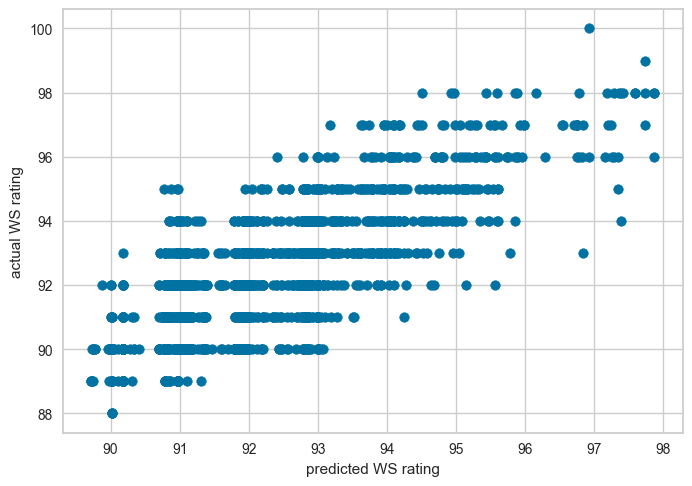

In [14]:
from matplotlib import pyplot as plt
fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(df['ws_pred'],df['WS'])
ax.set_xlabel('predicted WS rating')
ax.set_ylabel('actual WS rating')

In [15]:
def desire(h, low, target, high):
    if h <= low:
        return 0.0
    if h >= high:
        return 0.0
    if low < h <= target:
        return -low / (-low + target) + h / (-low + target)
    if target <= h < high:
        return 1.0 + target / (high - target) - h / (high - target)


In [16]:
from functools import partial

In [17]:
pdesire = partial(desire,low=0, target=5, high=100)

In [18]:
wdesire = partial(desire,low=89,target=100,high=105)

Text(0, 0.5, 'desire')

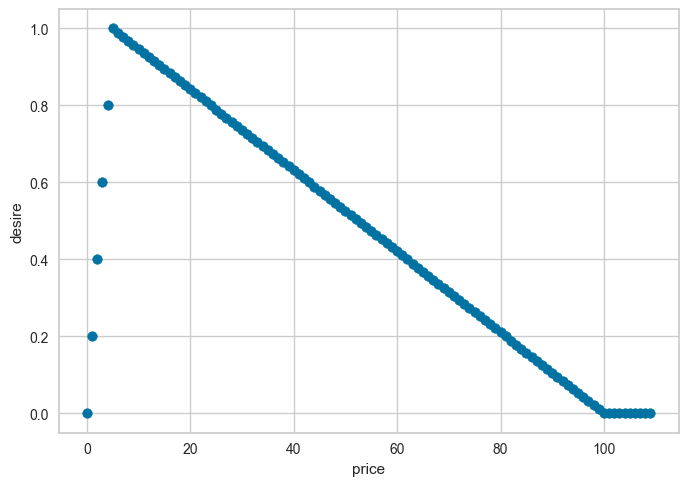

In [19]:
x=pd.Series(np.arange(0,110))
y=x.apply(pdesire)
fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(x,y)
ax.set_xlabel('price')
ax.set_ylabel('desire')

Text(0, 0.5, 'desire')

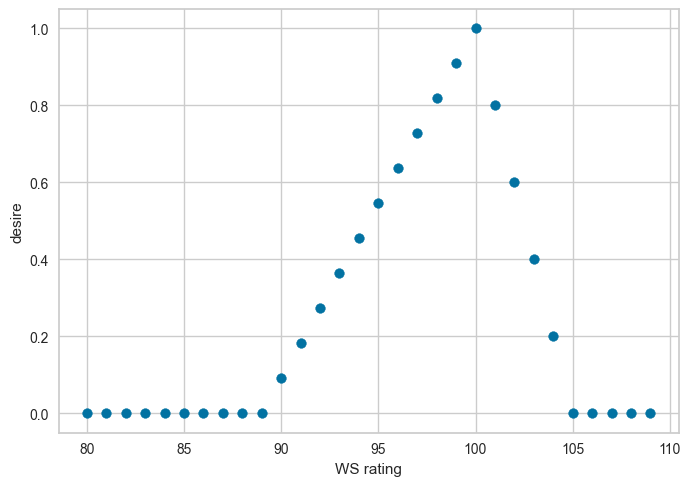

In [20]:
x=pd.Series(np.arange(80,110))
y=x.apply(wdesire)
fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(x,y)
ax.set_xlabel('WS rating')
ax.set_ylabel('desire')

In [21]:

def composite(pd,wd):
    return gmean([pd,wd],axis=0)
    

In [22]:
df['price_desire'] = df['price'].apply(pdesire)

In [23]:
df['ws_desire'] = df['WS'].apply(wdesire)

In [24]:
df['ws_pred_desire'] = df['ws_pred'].apply(wdesire)

In [25]:
df['composite_desire_pred'] = composite(df['price_desire'],df['ws_pred_desire'])

In [26]:
df['composite_desire'] = composite(df['price_desire'],df['ws_desire'])

In [33]:
list(df.sort_values('composite_desire',ascending=False).head(10)['wine_url'])

['https://www.wine.com/product/product/greywacke-sauvignon-blanc-2022/1203064',
 'https://www.wine.com/product/product/bedrock-wine-company-california-old-vine-zinfandel-2021/1199558',
 'https://www.wine.com/product/product/tenuta-di-capraia-chianti-classico-effe-55-gran-selezione-2018/1155021',
 'https://www.wine.com/product/product/penfolds-bin-28-shiraz-2020/1155677',
 'https://www.wine.com/product/product/viticcio-chianti-classico-riserva-2017/628038',
 'https://www.wine.com/product/product/allan-scott-marlborough-sauvignon-blanc-2022/1123978',
 'https://www.wine.com/product/product/invivo-x-by-sarah-jessica-parker-sauvignon-blanc-2022/1220918',
 'https://www.wine.com/product/product/penley-estate-phoenix-cabernet-sauvignon-2020/784232',
 'https://www.wine.com/product/product/dog-point-vineyard-section-94-sauvignon-blanc-2020/1232356',
 'https://www.wine.com/product/product/bodegas-valderiz-ribera-del-duero-2019/996467']

In [34]:
df.sort_values('composite_desire',ascending=False).head(10)[['name','productVarietal','WS','price']]

,name,productVarietal,WS,price
1455,Kevin Judd and Dixie,Sauvignon Blanc,95.0,23.99
33,2021 California Old Vine Zinfandel,Zinfandel,94.0,24.99
331,Tenuta di Capraia Winery Image,Sangiovese,95.0,38.99
157,Penfolds Chief Winemaker Peter Gago,Syrah/Shiraz,94.0,31.99
1328,The Hills of Chianti,Sangiovese,94.0,32.99
60,French puncheons for oak integration,Sauvignon Blanc,93.0,16.99
4752,Invivo X Winery Image,Sauvignon Blanc,93.0,17.99
827,Winemaker Matt Tilby,Cabernet Sauvignon,93.0,17.99
321,Old Vine,Sauvignon Blanc,95.0,45.99
2540,Bodegas Valderiz Winery Image,Tempranillo,94.0,35.99


In [32]:
list(df.sort_values('composite_desire_pred',ascending=False).head(10)['wine_url'])

['https://www.wine.com/product/product/weingut-fritz-windisch-heimersheimer-rotenfels-dornfelder-2022/1342571',
 'https://www.wine.com/product/product/tropical-mango-moscato/140923',
 'https://www.wine.com/product/product/wolffer-summer-in-a-bottle-cotes-de-provence-rose-2022/1224944',
 'https://www.wine.com/product/product/ca-furlan-cuvee-beatrice-extra-dry-prosecco/468139',
 'https://www.wine.com/product/product/loosen-bros-dr-l-riesling-2021/980879',
 'https://www.wine.com/product/product/ca-furlan-cuvee-mariana-prosecco-rose-2021/1025016',
 'https://www.wine.com/product/product/tropical-passion-fruit-moscato/140921',
 'https://www.wine.com/product/product/bodegas-muriel-reserva-2016/745672',
 'https://www.wine.com/product/product/wolffer-summer-in-a-bottle-long-island-rose-2022/1238605',
 'https://www.wine.com/product/product/domaine-salvard-cheverny-blanc-2022/1259643']

In [31]:
df.sort_values('composite_desire_pred',ascending=False).head(10)[['name','productVarietal','ws_pred','price']]

,name,productVarietal,ws_pred,price
9688,2022 Heimersheimer Rotenfels Dornfelder,Other Red Wine,94.021875,14.99
3694,Mango Moscato,Muscat,93.337500,14.99
46,Vineyards at Wölffer Estate Vineyard,Rosé,94.021875,26.99
10945,Ca' Furlan Winery Image,Non-Vintage Sparkling Wine,93.225000,16.99
325,Wehlen Slate,Riesling,92.793750,12.99
8043,Ca' Furlan Winery Image,Sparkling Rosé,92.793750,16.99
2393,Passion Fruit Moscato,Muscat,92.793750,17.99
327,Muriel Vineyards,Tempranillo,92.668750,15.99
109,Vineyards at Wölffer Estate Vineyard,Rosé,92.915625,25.99
6658,Domaine Salvard Winery Image,Sauvignon Blanc,92.793750,23.99
